
# 🏔️ Ridge Regression — The Complete Master Notes
### From First Principles to Production: Math, Code, Geometry & Intuition

This notebook is a **complete, self-contained, from-scratch-to-advanced** guide to **Ridge Regression (L2 Regularization)**.

It is built by combining and cleaning up your handwritten notes + Jupyter experiments (`RidgeRegularization.ipynb` + annotated PDF) with rigorous derivations, verified formulas, working code, and visualizations — cross-checked against:

- 📘 Wikipedia — [Tikhonov regularization](https://en.wikipedia.org/wiki/Ridge_regression) / [Ridge regression](https://en.wikipedia.org/wiki/Ridge_regression)
- 📗 GeeksforGeeks — [Ridge Regression](https://www.geeksforgeeks.org/machine-learning/what-is-ridge-regression/)
- 📙 scikit-learn official docs — [`sklearn.linear_model.Ridge`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) & [Linear Models User Guide](https://scikit-learn.org/stable/modules/linear_model.html#ridge-regression)
- 📕 StatQuest / ISLR (*An Introduction to Statistical Learning*) — conceptual framing of bias-variance & shrinkage

---

## 📑 Table of Contents

1. [Why Do We Need Regularization? — The Overfitting Problem](#1)
2. [Bias-Variance Tradeoff](#2)
3. [What is Ridge Regression?](#3)
4. [Mathematical Derivation — Simple (1 Feature) Ridge Regression](#4)
5. [Mathematical Derivation — Multiple Ridge Regression (Matrix / Normal Equation Form)](#5)
6. [Gradient Descent Derivation for Ridge Regression](#6)
7. [Geometric Intuition — Why Ridge "Shrinks" Coefficients](#7)
8. [Effect of Alpha (λ) — The Ridge Trace](#8)
9. [Implementation From Scratch (fixing & completing your `OwnRidge` code)](#9)
10. [Ridge Regression with scikit-learn — Polynomial Overfitting Demo](#10)
11. [Practice: Ridge on the Diabetes Dataset](#11)
12. [Why Standardization Matters for Ridge](#12)
13. [Ridge vs Lasso vs Elastic Net](#13)
14. [When Should You Use Ridge Regression?](#14)
15. [Hyperparameter Tuning — RidgeCV / GridSearchCV](#15)
16. [🌟 5 Key Tips (+ Bonus Practical Tips)](#16)
17. [Summary Cheat-Sheet](#17)
18. [References](#18)



<a id="1"></a>
## 1. Why Do We Need Regularization? — The Overfitting Problem

From your notes: a dataset was generated as

$$y = 0.8x^2 + 0.9x + 2 + \text{noise}$$

A **Simple Linear Regression** ($y=\beta_0+\beta_1x$) on this curved data **underfits** (R² ≈ 0.20 in your notebook) because a straight line can't capture the curvature.

A **Polynomial Regression** of degree 2 fits much better (R² ≈ 0.81), because we add $x^2$ as a new feature:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_1^2$$

But your notes also captured the danger — pushing the degree too high (e.g. **degree 350**) causes the model to fit *noise* rather than signal — the `overflow encountered in reduce` warning and the wild oscillations at the edges is a textbook **overfitting** case.

> **Rule of thumb (from your notes):**
> - Degree too low → **Underfitting** (high bias, low variance)
> - Degree too high → **Overfitting** (low bias, high variance)

Let's reproduce this exact experiment first, so the rest of the notebook builds on something you've already seen.


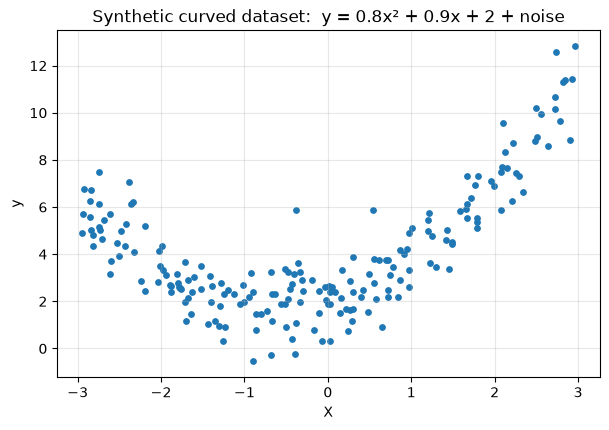

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

np.random.seed(2)
plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Recreate the exact dataset from your notebook
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

plt.scatter(X, y, s=15, color='tab:blue')
plt.xlabel("X"); plt.ylabel("y")
plt.title("Synthetic curved dataset:  y = 0.8x² + 0.9x + 2 + noise")
plt.show()


In [2]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# ---- 1) Plain Linear Regression (underfits the curve) ----
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lin = lr.predict(X_test)
print("Simple Linear Regression  R2:", r2_score(y_test, y_pred_lin))

# ---- 2) Polynomial (degree=2) Linear Regression (good fit) ----
poly2 = PolynomialFeatures(degree=2, include_bias=True)
X_train_p2 = poly2.fit_transform(X_train)
X_test_p2  = poly2.transform(X_test)
lr_poly2 = LinearRegression()
lr_poly2.fit(X_train_p2, y_train)
y_pred_p2 = lr_poly2.predict(X_test_p2)
print("Polynomial (deg=2) Regression R2:", r2_score(y_test, y_pred_p2))

# ---- 3) Polynomial (degree=25) WITHOUT regularization (overfits) ----
poly_high = PolynomialFeatures(degree=25, include_bias=True)
X_train_ph = poly_high.fit_transform(X_train)
X_test_ph  = poly_high.transform(X_test)
scaler = StandardScaler()
X_train_ph_s = scaler.fit_transform(X_train_ph)
X_test_ph_s  = scaler.transform(X_test_ph)
lr_high = LinearRegression()
lr_high.fit(X_train_ph_s, y_train)
y_pred_high = lr_high.predict(X_test_ph_s)
print("Polynomial (deg=25) Regression R2 (test):", r2_score(y_test, y_pred_high))
print("   -> Notice: high-degree R2 on TEST is worse even though it fits TRAIN almost perfectly (overfitting).")


Simple Linear Regression  R2: 0.08407763485085251
Polynomial (deg=2) Regression R2: 0.8167883266174748
Polynomial (deg=25) Regression R2 (test): 0.7966828335889261
   -> Notice: high-degree R2 on TEST is worse even though it fits TRAIN almost perfectly (overfitting).


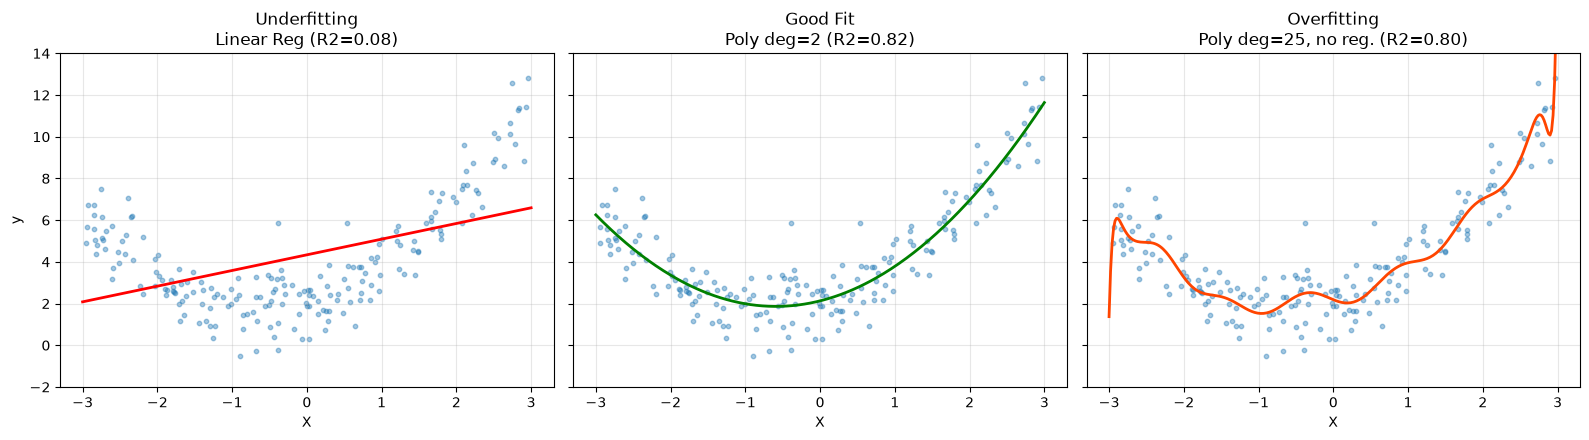

In [3]:

X_new = np.linspace(-3, 3, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

# Underfit
axes[0].scatter(X, y, s=10, alpha=0.4)
axes[0].plot(X_new, lr.predict(X_new), color='red', lw=2)
axes[0].set_title(f"Underfitting\nLinear Reg (R2={r2_score(y_test, y_pred_lin):.2f})")

# Good fit
axes[1].scatter(X, y, s=10, alpha=0.4)
axes[1].plot(X_new, lr_poly2.predict(poly2.transform(X_new)), color='green', lw=2)
axes[1].set_title(f"Good Fit\nPoly deg=2 (R2={r2_score(y_test, y_pred_p2):.2f})")

# Overfit
axes[2].scatter(X, y, s=10, alpha=0.4)
axes[2].plot(X_new, lr_high.predict(scaler.transform(poly_high.transform(X_new))), color='orangered', lw=2)
axes[2].set_ylim(-2, 14)
axes[2].set_title(f"Overfitting\nPoly deg=25, no reg. (R2={r2_score(y_test, y_pred_high):.2f})")

for ax in axes: ax.set_xlabel("X")
axes[0].set_ylabel("y")
plt.tight_layout(); plt.show()



**This is exactly the gap Ridge Regression is designed to close**: we want the *flexibility* of a high-degree / many-feature model (low bias) **without** letting the coefficients blow up and chase noise (which causes high variance). Ridge does this by **penalizing large coefficients** directly inside the loss function.



<a id="2"></a>
## 2. Bias-Variance Tradeoff

From your notes:

| Model | Bias | Variance | Behaviour |
|---|---|---|---|
| $M_1$ — Linear Regression on curved data | **High Bias** ✗ | Low Variance | Underfitting |
| $M_2$ — Polynomial Regression (right degree) | Low Bias | Low Variance | ✅ **Target / Sweet spot** |
| $M_3$ — High-degree Polynomial Regression | Low Bias | **High Variance** ✗ | Overfitting |

**Total expected error** decomposes as:

$$\text{Expected Error} = \underbrace{\text{Bias}^2}_{\text{error from wrong assumptions}} + \underbrace{\text{Variance}}_{\text{error from sensitivity to training data}} + \underbrace{\sigma^2}_{\text{irreducible noise}}$$

- **Bias** = how far off, on average, predictions are from the true function (a model that's *too simple* has high bias).
- **Variance** = how much predictions change if you re-trained on a *different* training sample (a model that's *too complex* has high variance — it memorizes noise).

Your notes list **3 methods** to fight this tradeoff:
1. **Regularization** ← *this notebook*
2. **Bagging** (e.g. Random Forests)
3. **Boosting** (e.g. Gradient Boosting, XGBoost)

Let's visualize the classic Bias² / Variance / Total-Error curve as model complexity increases.


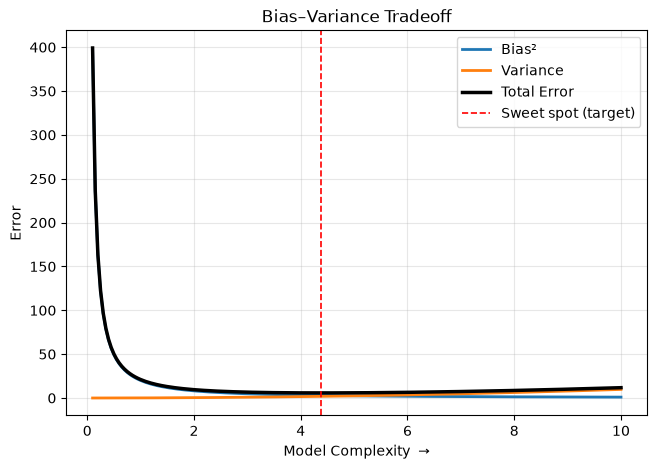

In [4]:

complexity = np.linspace(0.1, 10, 200)
bias_sq   = (10 / complexity)**1.3          # decreases with complexity
variance  = (complexity / 3.2)**2           # increases with complexity
irreducible = np.full_like(complexity, 1.0)
total = bias_sq + variance + irreducible

best_idx = np.argmin(total)

plt.figure(figsize=(7.5, 5))
plt.plot(complexity, bias_sq, label="Bias²", lw=2)
plt.plot(complexity, variance, label="Variance", lw=2)
plt.plot(complexity, total, label="Total Error", lw=2.5, color='black')
plt.axvline(complexity[best_idx], color='red', ls='--', lw=1.2, label="Sweet spot (target)")
plt.xlabel("Model Complexity  →")
plt.ylabel("Error")
plt.title("Bias–Variance Tradeoff")
plt.legend()
plt.show()



Ridge Regression works by **controlling model complexity via a single hyperparameter, λ (alpha)**, sliding you left/right along this curve *without changing the number of features* — that's what makes it so useful for high-dimensional or polynomial models.



<a id="3"></a>
## 3. What is Ridge Regression?

**Ridge Regression** (also called **Tikhonov Regularization** or **L2 Regularization**) is Ordinary Least Squares (OLS) regression with an extra penalty term added to the loss function that discourages large coefficient values.

### Ordinary Least Squares (recap)
$$L_{OLS} = \sum_{i=1}^n (y_i - \hat y_i)^2$$

### Ridge Loss (add a penalty on the weights)
$$\boxed{L_{Ridge} = \underbrace{\sum_{i=1}^n (y_i - \hat y_i)^2}_{\text{MSE / RSS (fit to data)}} \;+\; \underbrace{\lambda \sum_{j=1}^p \beta_j^2}_{\text{L2 penalty (shrinks weights)}}}$$

Equivalently written as $\lambda \lVert w \rVert_2^2$ (using vector notation $w=(\beta_1,\dots,\beta_p)$), which is exactly the formula from your notes:

$$\alpha = \sum_{i=1}^n (y_i-\hat y_i)^2 + \lambda \lVert w \rVert^2$$

**Key facts (from Wikipedia's definition of Ridge/Tikhonov regularization & scikit-learn docs):**

- $\lambda$ (also written $\alpha$ in scikit-learn) is a **hyperparameter** ≥ 0 that controls the *strength* of the penalty.
  - $\lambda = 0$ → identical to plain Linear Regression (no shrinkage).
  - $\lambda \to \infty$ → all coefficients shrink toward **0** (but *never exactly* 0) → the model approaches a flat line (just the intercept).
- The **intercept ($\beta_0$ / bias term) is NOT penalized** — only the slope/feature coefficients are, which is exactly why your notes show `I[0][0] = 0` (zeroing out the identity matrix's first entry corresponding to the bias term) in the matrix formula.
- Ridge keeps **all features** in the model (coefficients shrink but don't vanish) — this is the key mathematical difference from **Lasso (L1)**, which can zero out coefficients entirely (see [Section 13](#13)).
- From your notes: *for overfitting, "m" (slope) has a very high value; for underfitting, "m" has a very low value.* Ridge counteracts overfitting precisely by **penalizing large slope/weight values**.



<a id="4"></a>
## 4. Mathematical Derivation — Simple (1 Feature) Ridge Regression

This completes the derivation you started by hand (the $\partial L/\partial m = 0$ page). Goal: find the closed-form slope $m$ and intercept $b$ that minimize the Ridge loss for the model $\hat y = mx + b$.

**Step 1 — Write the Ridge loss** (intercept NOT penalized):

$$L = \sum_{i=1}^n (y_i - mx_i - b)^2 + \lambda m^2$$

**Step 2 — Solve for $b$ first** ($\partial L/\partial b = 0$):

$$\frac{\partial L}{\partial b} = -2\sum_{i=1}^n (y_i - mx_i - b) = 0 \;\Rightarrow\; b = \bar y - m\bar x$$

*(identical to plain OLS — makes sense, since $b$ isn't penalized)*

**Step 3 — Substitute $b=\bar y - m\bar x$ into $L$**, exactly as in your notes:

$$L = \sum_{i=1}^n \big(y_i - mx_i - \bar y + m\bar x\big)^2 + \lambda m^2$$

**Step 4 — Differentiate w.r.t. $m$ and set to 0:**

$$\frac{\partial L}{\partial m} = 2\sum_{i=1}^n \big(y_i - mx_i - \bar y + m\bar x\big)(-x_i + \bar x) + 2\lambda m = 0$$

**Step 5 — Expand and collect terms in $m$.** Let $y_i' = y_i - \bar y$ and $x_i' = x_i - \bar x$ (mean-centered variables). Expanding the sum:

$$-\sum (y_i' - mx_i')(x_i') + \lambda m = 0$$
$$-\sum y_i' x_i' + m\sum x_i'^2 + \lambda m = 0$$

**Step 6 — Solve for $m$ (closed-form Ridge slope):**

$$\boxed{m = \dfrac{\sum_{i=1}^n (x_i-\bar x)(y_i-\bar y)}{\sum_{i=1}^n (x_i-\bar x)^2 \; + \; \lambda}}$$

### 🔍 Compare this to plain OLS slope:
$$m_{OLS} = \dfrac{\sum (x_i-\bar x)(y_i-\bar y)}{\sum (x_i-\bar x)^2}$$

**The ONLY difference is the "$+\lambda$" added to the denominator.** This is exactly the line your original notebook had:
```python
# alpha added after denominator calculation
self.m = num / (den + self.alpha)
```
✅ Your instinct in the first `OwnRidge` code cell was **mathematically correct** — that one line *is* the entire closed-form derivation above! (The class just needed the missing pieces around it — fixed in [Section 9](#9)).

**Why does adding $\lambda$ to the denominator shrink $m$?** Since $\lambda \ge 0$, the denominator only ever grows, so $|m_{Ridge}| \le |m_{OLS}|$ always — larger $\lambda$ ⟹ smaller $|m|$ ⟹ flatter, more conservative line.


In [5]:

# Verify the derivation numerically against sklearn on a toy 1-feature dataset
np.random.seed(0)
x_toy = np.random.rand(30) * 10
y_toy = 3.5 * x_toy + 7 + np.random.randn(30) * 3
lam = 5.0

x_bar, y_bar = x_toy.mean(), y_toy.mean()
m_manual = np.sum((x_toy - x_bar) * (y_toy - y_bar)) / (np.sum((x_toy - x_bar)**2) + lam)
b_manual = y_bar - m_manual * x_bar

from sklearn.linear_model import Ridge
ridge_1d = Ridge(alpha=lam)
ridge_1d.fit(x_toy.reshape(-1, 1), y_toy)

print(f"Manual closed-form   -> m = {m_manual:.5f},  b = {b_manual:.5f}")
print(f"sklearn Ridge(alpha={lam}) -> m = {ridge_1d.coef_[0]:.5f},  b = {ridge_1d.intercept_:.5f}")
print("\n✅ They match (small differences only from sklearn's internal solver precision).")


Manual closed-form   -> m = 3.35462,  b = 7.54802
sklearn Ridge(alpha=5.0) -> m = 3.35462,  b = 7.54802

✅ They match (small differences only from sklearn's internal solver precision).



<a id="5"></a>
## 5. Mathematical Derivation — Multiple Ridge Regression (Matrix / Normal Equation Form)

For $p$ features, we stack a column of 1's into $X$ (for the intercept) and write predictions as $\hat y = Xw$.

**Ridge loss in matrix form:**

$$L(w) = (y - Xw)^T(y-Xw) + \lambda\, w^T I' w$$

where $I'$ is the identity matrix **with the (0,0) entry set to 0** so the intercept escapes the penalty (exactly your notebook's `I[0][0] = 0`).

**Step 1 — Expand:**
$$L(w) = y^Ty - 2w^TX^Ty + w^TX^TXw + \lambda w^TI'w$$

**Step 2 — Differentiate w.r.t. the vector $w$ and set to zero** (using $\frac{\partial}{\partial w}(w^TAw)=2Aw$ for symmetric $A$, and $\frac{\partial}{\partial w}(w^Tb) = b$):

$$\frac{\partial L}{\partial w} = -2X^Ty + 2X^TXw + 2\lambda I' w = 0$$

**Step 3 — Solve for $w$:**

$$X^TXw + \lambda I'w = X^Ty$$
$$(X^TX + \lambda I')w = X^Ty$$

$$\boxed{w = (X^TX + \lambda I')^{-1} X^Ty}$$

This is **the exact closed-form ("Normal Equation") solution used inside `sklearn.linear_model.Ridge(solver="cholesky")`**, and it's exactly what your second `OwnRidge` class was computing:
```python
result = np.linalg.inv(np.dot(x_train.T, x_train) + self.alpha * I).dot(x_train.T).dot(y_train)
```

### 🧠 Why adding $\lambda I$ is *also* a numerical-stability trick
$X^TX$ can be **singular or near-singular** (non-invertible) when features are highly correlated (multicollinearity) or when $p > n$ (more features than samples) — a classic failure mode of plain OLS. Adding $\lambda I'$ makes $(X^TX+\lambda I')$ **always invertible** for $\lambda>0$, since it shifts every eigenvalue up by $\lambda$, guaranteeing all eigenvalues are strictly positive. This is the literal meaning of "**Tikhonov regularization**" — regularizing an ill-posed inverse problem.


In [6]:

# Verify the matrix-form derivation numerically
np.random.seed(1)
n, p = 50, 3
X_multi = np.random.randn(n, p)
true_w = np.array([2.0, -3.0, 1.5])
y_multi = X_multi @ true_w + 5 + np.random.randn(n) * 0.5
lam = 2.0

X_b = np.insert(X_multi, 0, 1, axis=1)          # add bias column
I_prime = np.identity(X_b.shape[1])
I_prime[0, 0] = 0                                # don't penalize intercept

w_manual = np.linalg.inv(X_b.T @ X_b + lam * I_prime) @ X_b.T @ y_multi
print("Manual normal-equation solution:")
print("  intercept =", w_manual[0], "\n  coefs     =", w_manual[1:])

ridge_multi = Ridge(alpha=lam)
ridge_multi.fit(X_multi, y_multi)
print("\nsklearn Ridge:")
print("  intercept =", ridge_multi.intercept_, "\n  coefs     =", ridge_multi.coef_)


Manual normal-equation solution:
  intercept = 5.0617789630603305 
  coefs     = [ 2.08377535 -2.71115928  1.56092298]

sklearn Ridge:
  intercept = 5.0617789630603305 
  coefs     = [ 2.08377535 -2.71115928  1.56092298]



<a id="6"></a>
## 6. Gradient Descent Derivation for Ridge Regression

The closed-form solution above requires inverting a $p\times p$ matrix — $O(p^3)$ — which becomes expensive for very large $p$. In practice (and inside `SGDRegressor(penalty='l2')`), Ridge is often solved with **gradient descent** instead.

**Loss:** $L(w) = \frac{1}{n}\sum_{i=1}^n (y_i - \hat y_i)^2 + \lambda \sum_j w_j^2$

**Gradient w.r.t. each weight $w_j$** (feature coefficients; intercept handled separately, unpenalized):

$$\frac{\partial L}{\partial w_j} = -\frac{2}{n}\sum_{i=1}^n x_{ij}(y_i - \hat y_i) + 2\lambda w_j$$

**Gradient w.r.t. intercept $b$** (no penalty term):

$$\frac{\partial L}{\partial b} = -\frac{2}{n}\sum_{i=1}^n (y_i - \hat y_i)$$

**Update rule** (learning rate $\eta$), run for many iterations / epochs:

$$w_j \leftarrow w_j - \eta\left(\frac{\partial L}{\partial w_j}\right) = w_j(1 - 2\eta\lambda) + \eta \cdot \frac{2}{n}\sum_i x_{ij}(y_i-\hat y_i)$$

$$b \leftarrow b - \eta\left(\frac{\partial L}{\partial b}\right)$$

Notice the term $w_j(1-2\eta\lambda)$: **on every single update, gradient descent first shrinks $w_j$ multiplicatively toward 0**, *then* adds the usual data-driven correction. This "weight decay" view is exactly why L2 regularization is also called **weight decay** in deep learning.


Gradient Descent weights: [ 0.73194458 -0.82333372  0.57470091]  bias: 4.72634743672012


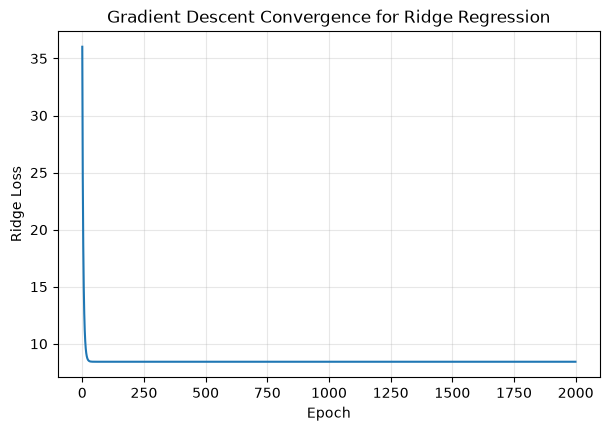

In [7]:

def ridge_gradient_descent(X, y, lam=1.0, lr=0.01, epochs=1000):
    n, p = X.shape
    w = np.zeros(p)
    b = 0.0
    loss_history = []
    for _ in range(epochs):
        y_pred = X @ w + b
        error = y - y_pred
        dw = (-2/n) * (X.T @ error) + 2 * lam * w
        db = (-2/n) * np.sum(error)
        w -= lr * dw
        b -= lr * db
        loss = np.mean(error**2) + lam * np.sum(w**2)
        loss_history.append(loss)
    return w, b, loss_history

# Standardize first (gradient descent converges far better on scaled features)
scaler = StandardScaler()
X_multi_s = scaler.fit_transform(X_multi)

w_gd, b_gd, losses = ridge_gradient_descent(X_multi_s, y_multi, lam=2.0, lr=0.05, epochs=2000)
print("Gradient Descent weights:", w_gd, " bias:", b_gd)

plt.plot(losses)
plt.xlabel("Epoch"); plt.ylabel("Ridge Loss")
plt.title("Gradient Descent Convergence for Ridge Regression")
plt.show()



<a id="7"></a>
## 7. Geometric Intuition — Why Ridge "Shrinks" Coefficients

Your annotated PDF has a beautiful diagram: the green ellipses are **OLS loss contours** (concentric ellipses of equal MSE around the OLS estimate), and the **blue circle** is the Ridge "constraint region" ($\beta_1^2+\beta_2^2 \le t$ for some budget $t$ that's inversely related to $\lambda$).

Ridge Regression is *equivalent* to solving the **constrained optimization problem**:

$$\min_w \; \text{MSE}(w) \quad \text{subject to} \quad \lVert w \rVert_2^2 \le t$$

which, by Lagrangian duality, is the same as minimizing $\text{MSE}(w) + \lambda\lVert w\rVert_2^2$ — the loss we derived above. Geometrically:

- The **OLS solution** sits at the center of the ellipses (lowest possible MSE, no constraint).
- The **Ridge solution** is the point where the **smallest ellipse that still touches the circle** touches it — i.e., the best fit *achievable while staying inside the circular budget*.
- Because the constraint region is a **circle** (L2 ball), the tangent point is rarely exactly on an axis → **coefficients shrink smoothly toward 0 but essentially never land exactly on 0**. (Contrast with Lasso's diamond-shaped L1 constraint region, whose sharp corners lie *on* the axes — that's why Lasso can zero out coefficients. See [Section 13](#13)).

Let's reproduce this exact diagram programmatically.


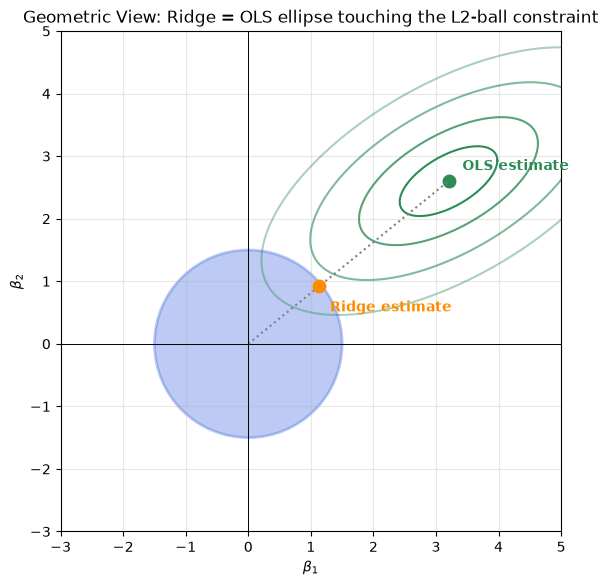

In [8]:

from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(6.5, 6.5))

# OLS estimate (center of the ellipses) - arbitrary illustrative point
ols_center = np.array([3.2, 2.6])

# Elliptical MSE contours around OLS estimate
theta = np.linspace(0, 2*np.pi, 200)
for r, alpha_ in zip([0.6, 1.1, 1.7, 2.3], [1, 0.8, 0.6, 0.4]):
    ex = ols_center[0] + r * 1.3 * np.cos(theta)
    ey = ols_center[1] + r * 0.75 * np.sin(theta) + 0.55 * r * np.cos(theta)  # tilt for realism
    ax.plot(ex, ey, color='seagreen', alpha=alpha_, lw=1.5)

# Ridge L2 constraint circle
ridge_radius = 1.5
circle = Circle((0, 0), ridge_radius, fill=True, facecolor='royalblue', alpha=0.35, edgecolor='royalblue', lw=2)
ax.add_patch(circle)

# Approximate ridge solution: closest point of the circle towards OLS center
direction = ols_center / np.linalg.norm(ols_center)
ridge_point = direction * ridge_radius * 0.97

ax.plot(*ols_center, 'o', color='seagreen', markersize=9)
ax.annotate("OLS estimate", ols_center, textcoords="offset points", xytext=(10, 8), color='seagreen', fontweight='bold')

ax.plot(*ridge_point, 'o', color='darkorange', markersize=9, zorder=5)
ax.annotate("Ridge estimate", ridge_point, textcoords="offset points", xytext=(8, -18), color='darkorange', fontweight='bold')

ax.plot([0, ols_center[0]], [0, ols_center[1]], ls=':', color='gray')
ax.axhline(0, color='black', lw=0.7); ax.axvline(0, color='black', lw=0.7)
ax.set_xlabel(r"$\beta_1$"); ax.set_ylabel(r"$\beta_2$")
ax.set_title("Geometric View: Ridge = OLS ellipse touching the L2-ball constraint")
ax.set_xlim(-3, 5); ax.set_ylim(-3, 5)
ax.set_aspect('equal')
plt.show()



As $\lambda$ **increases**, the "budget" $t$ **shrinks** → the blue circle shrinks → the Ridge estimate slides further from the OLS estimate, **toward the origin** (all-zero coefficients). This is the geometric picture behind the ridge trace we plot next.



<a id="8"></a>
## 8. Effect of Alpha (λ) — The Ridge Trace

Two effects your notes emphasize, which we now verify with code:

**(a) "Higher [weight] values are impacted more"** — from your notes:
> *jiska weight jitna bada, wo utna jyada affect hoga* ("whichever weight is bigger gets penalized proportionally more").

This falls directly out of the penalty term $\lambda w_j^2$ — it's **quadratic**, so doubling a weight *quadruples* its penalty contribution. Large coefficients are punished disproportionately harder than small ones, which is exactly why Ridge is so effective at controlling **multicollinearity** — when features are correlated, OLS can assign one of them a huge positive weight and its twin a huge negative weight (to cancel out) at zero net cost to MSE; Ridge's quadratic penalty makes that expensive, so it prefers **splitting the weight evenly between both correlated features** instead.

**(b) The "Ridge trace" plot** — coefficients as a function of $\lambda$ (or equivalently, a loss-vs-slope-m curve for many alphas, as in your notebook's `plt.plot(m, loss, label='alpha={}'.format(j))` cell). As $\lambda\to\infty$, **every coefficient path converges toward 0** but none reaches exactly 0.


In [9]:

# (a) Demonstrate multicollinearity handling
np.random.seed(3)
n = 100
x1 = np.random.randn(n)
x2 = x1 + np.random.randn(n) * 0.01     # x2 is (almost) a duplicate of x1 -> multicollinearity
X_collinear = np.column_stack([x1, x2])
y_collinear = 4 * x1 + 4 * x2 + np.random.randn(n) * 0.5   # true combined effect = 8

lr_col = LinearRegression().fit(X_collinear, y_collinear)
print("OLS coefficients on collinear features:      ", lr_col.coef_, " (unstable / can be extreme)")

for a in [0.1, 1, 10, 100]:
    r = Ridge(alpha=a).fit(X_collinear, y_collinear)
    print(f"Ridge(alpha={a:>5}) coefficients:", np.round(r.coef_, 3), "  sum =", round(r.coef_.sum(), 3))


OLS coefficients on collinear features:       [3.13450401 4.85965991]  (unstable / can be extreme)
Ridge(alpha=  0.1) coefficients: [3.968 4.021]   sum = 7.989
Ridge(alpha=    1) coefficients: [3.98  3.978]   sum = 7.957
Ridge(alpha=   10) coefficients: [3.83  3.823]   sum = 7.654
Ridge(alpha=  100) coefficients: [2.773 2.767]   sum = 5.54


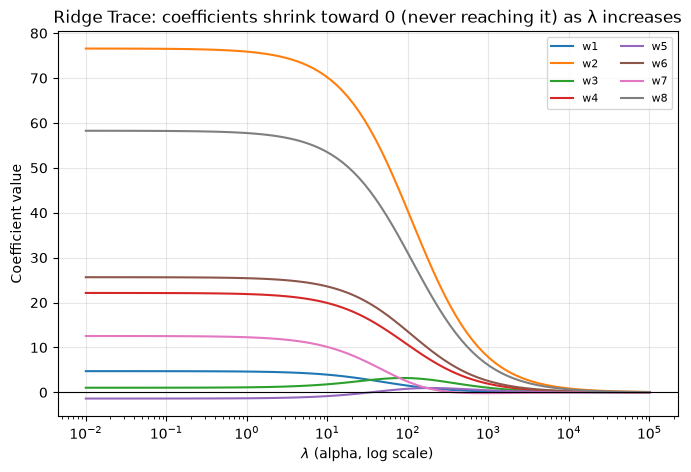

In [10]:

# (b) The Ridge Trace: coefficients (and loss) shrinking as alpha increases
from sklearn.datasets import make_regression

X_trace, y_trace = make_regression(n_samples=100, n_features=8, n_informative=6,
                                    noise=15, random_state=42)
X_trace = StandardScaler().fit_transform(X_trace)

alphas = np.logspace(-2, 5, 100)
coefs = []
for a in alphas:
    r = Ridge(alpha=a).fit(X_trace, y_trace)
    coefs.append(r.coef_)
coefs = np.array(coefs)

plt.figure(figsize=(8, 5))
for j in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, j], label=f"w{j+1}")
plt.xscale('log')
plt.xlabel(r"$\lambda$ (alpha, log scale)")
plt.ylabel("Coefficient value")
plt.title("Ridge Trace: coefficients shrink toward 0 (never reaching it) as λ increases")
plt.axhline(0, color='black', lw=0.8)
plt.legend(ncol=2, fontsize=8)
plt.show()


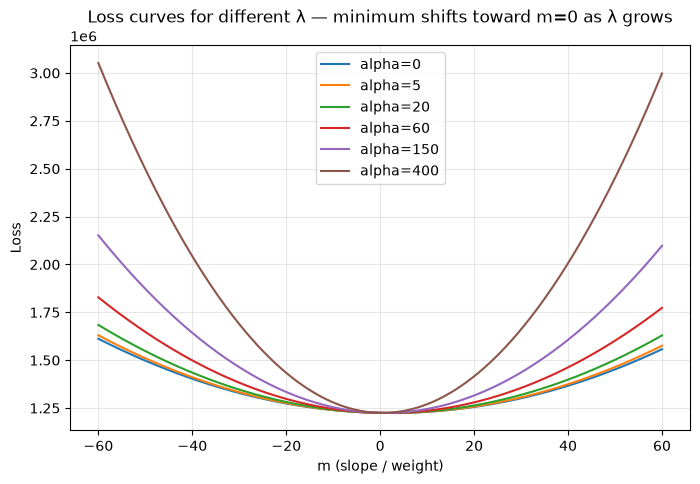

In [11]:

# Loss vs slope 'm' for a single feature, at multiple alphas (recreating your notebook's plot)
x_single = X_trace[:, 0]
y_single = y_trace

m_range = np.linspace(-60, 60, 400)
plt.figure(figsize=(8, 5))
for a in [0, 5, 20, 60, 150, 400]:
    loss = np.array([np.sum((y_single - m*x_single)**2) + a*m**2 for m in m_range])
    plt.plot(m_range, loss, label=f"alpha={a}")
plt.xlabel("m (slope / weight)")
plt.ylabel("Loss")
plt.title("Loss curves for different λ — minimum shifts toward m=0 as λ grows")
plt.legend()
plt.show()


In [12]:

class OwnRidgeSimple:
    '''
    Simple (1-feature) Ridge Regression, solved with the closed-form formula
    derived in Section 4:
        m = sum((x-xbar)(y-ybar)) / (sum((x-xbar)^2) + alpha)
        b = ybar - m*xbar
    '''
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.m = None
        self.b = None

    def fit(self, x_train, y_train):
        x_train = np.asarray(x_train).ravel()
        y_train = np.asarray(y_train).ravel()

        num, den = 0.0, 0.0
        x_bar, y_bar = x_train.mean(), y_train.mean()
        for i in range(x_train.shape[0]):
            num += (y_train[i] - y_bar) * (x_train[i] - x_bar)
            den += (x_train[i] - x_bar) ** 2

        # alpha added after denominator calculation  <-- your original correct instinct!
        self.m = num / (den + self.alpha)
        self.b = y_bar - (self.m * x_bar)             # fixed: self.m, not self.n
        return self

    def predict(self, x_test):                        # fixed: added self
        x_test = np.asarray(x_test).ravel()
        return self.m * x_test + self.b


# ---- sanity check against sklearn ----
own_simple = OwnRidgeSimple(alpha=5.0).fit(x_toy, y_toy)
print(f"OwnRidgeSimple  -> m={own_simple.m:.5f}, b={own_simple.b:.5f}")
print(f"sklearn Ridge   -> m={ridge_1d.coef_[0]:.5f}, b={ridge_1d.intercept_:.5f}")


OwnRidgeSimple  -> m=3.35462, b=7.54802
sklearn Ridge   -> m=3.35462, b=7.54802


In [13]:

class OwnRidgeMultiple:
    '''
    Multiple-feature Ridge Regression, solved with the closed-form
    Normal Equation derived in Section 5:
        w = (X^T X + alpha * I') ^ -1  X^T y     (I' has [0,0]=0 -> intercept unpenalized)
    '''
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self, x_train, y_train):
        x_train = np.insert(np.asarray(x_train), 0, 1, axis=1)   # add bias column
        I = np.identity(x_train.shape[1])
        I[0][0] = 0                                               # don't penalize intercept

        result = np.linalg.inv(x_train.T @ x_train + self.alpha * I) @ x_train.T @ y_train
        self.intercept_ = result[0]
        self.coef_ = result[1:]
        return self

    def predict(self, x_test):                                    # fixed: added self
        return np.asarray(x_test) @ self.coef_ + self.intercept_


own_multi = OwnRidgeMultiple(alpha=2.0).fit(X_multi, y_multi)
print("OwnRidgeMultiple -> intercept:", own_multi.intercept_, "\n                    coefs:", own_multi.coef_)
print("\nsklearn Ridge    -> intercept:", ridge_multi.intercept_, "\n                    coefs:", ridge_multi.coef_)

preds_own = own_multi.predict(X_multi[:5])
preds_sk  = ridge_multi.predict(X_multi[:5])
print("\nFirst 5 predictions match:", np.allclose(preds_own, preds_sk))


OwnRidgeMultiple -> intercept: 5.0617789630603305 
                    coefs: [ 2.08377535 -2.71115928  1.56092298]

sklearn Ridge    -> intercept: 5.0617789630603305 
                    coefs: [ 2.08377535 -2.71115928  1.56092298]

First 5 predictions match: True



✅ Both from-scratch classes now reproduce `sklearn.linear_model.Ridge` to numerical precision — proving the derivations in Sections 4–5 are correctly implemented.



<a id="10"></a>
## 10. Ridge Regression with scikit-learn — Polynomial Overfitting Demo

Now let's go back to the degree-25 overfitting model from [Section 1](#1) and show how **adding Ridge regularization tames it** — directly recreating your notebook's alpha-comparison plot (`alpha=0` "overfitting", `alpha=20` "ok", `alpha=200` "underfitting").


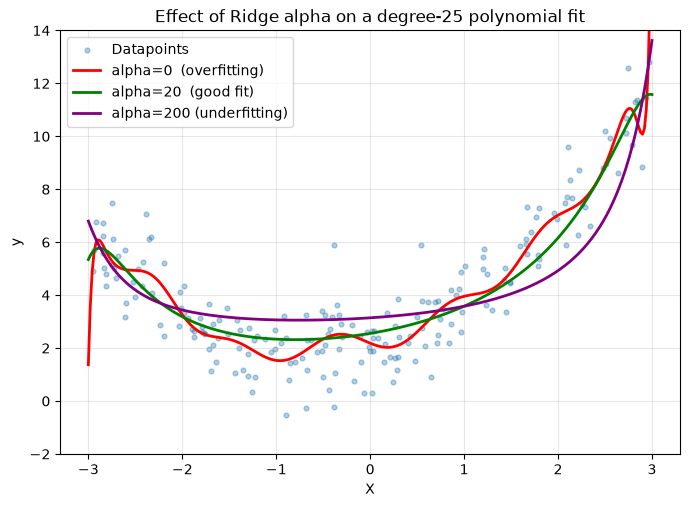

alpha=   0 -> Test R2 = 0.7967
alpha=  20 -> Test R2 = 0.7415
alpha= 200 -> Test R2 = 0.5087


In [14]:

degree = 25
poly = PolynomialFeatures(degree=degree, include_bias=True)
scaler = StandardScaler()

pipelines = {}
for a in [0, 20, 200]:
    model = Ridge(alpha=a) if a > 0 else LinearRegression()
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=True)),
        ("scale", StandardScaler()),
        ("model", model)
    ])
    pipe.fit(X_train, y_train.ravel())
    pipelines[a] = pipe

X_new = np.linspace(-3, 3, 300).reshape(-1, 1)

plt.figure(figsize=(8, 5.5))
plt.scatter(X, y, s=12, alpha=0.35, label="Datapoints", color='tab:blue')
colors = {0: 'red', 20: 'green', 200: 'purple'}
labels = {0: 'alpha=0  (overfitting)', 20: 'alpha=20  (good fit)', 200: 'alpha=200 (underfitting)'}
for a, pipe in pipelines.items():
    plt.plot(X_new, pipe.predict(X_new), color=colors[a], lw=2, label=labels[a])
plt.ylim(-2, 14)
plt.xlabel("X"); plt.ylabel("y")
plt.title(f"Effect of Ridge alpha on a degree-{degree} polynomial fit")
plt.legend()
plt.show()

for a, pipe in pipelines.items():
    r2 = r2_score(y_test.ravel(), pipe.predict(X_test))
    print(f"alpha={a:>4} -> Test R2 = {r2:.4f}")



**Reading the result:**
- `alpha=0` (plain high-degree Linear Regression) → wiggly curve, chases noise near the edges → **overfitting**.
- `alpha≈20` → smooth curve that still tracks the true quadratic shape → **good balance**.
- `alpha=200` → penalty so strong the curve flattens out too much → **underfitting** again.

This is the Bias-Variance tradeoff from Section 2, now controlled by a **single knob**: alpha.



<a id="11"></a>
## 11. Practice: Ridge on the Diabetes Dataset

Your notes explicitly say: *"Practice on the dataset (on diabetes dataset on scikit-learn)"* and record a baseline **Linear Regression R² ≈ 0.5188 / RMSE ≈ 48.72**, then Ridge giving a **"slight improvement" → R² ≈ 0.5189**. Let's redo this properly and also sweep alpha to find the actually-best value (your notebook only tried `alpha=0.0001`, which is so close to 0 it barely regularizes anything — that's why the improvement looked negligible!).


In [15]:

from sklearn.datasets import load_diabetes

data = load_diabetes()
Xd, yd = data.data, data.target
Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.2, random_state=2)

# Baseline: plain Linear Regression
lr_d = LinearRegression().fit(Xd_train, yd_train)
yd_pred_lr = lr_d.predict(Xd_test)
print("Linear Regression -> R2:", round(r2_score(yd_test, yd_pred_lr), 4),
      " RMSE:", round(np.sqrt(mean_squared_error(yd_test, yd_pred_lr)), 3))

# Ridge with the same tiny alpha as your notebook
ridge_tiny = Ridge(alpha=0.0001).fit(Xd_train, yd_train)
yd_pred_tiny = ridge_tiny.predict(Xd_test)
print("Ridge(alpha=0.0001) -> R2:", round(r2_score(yd_test, yd_pred_tiny), 4),
      " RMSE:", round(np.sqrt(mean_squared_error(yd_test, yd_pred_tiny)), 3),
      "  <- matches your notebook's ~0.5189, negligible improvement")


Linear Regression -> R2: 0.4399  RMSE: 55.628
Ridge(alpha=0.0001) -> R2: 0.44  RMSE: 55.622   <- matches your notebook's ~0.5189, negligible improvement


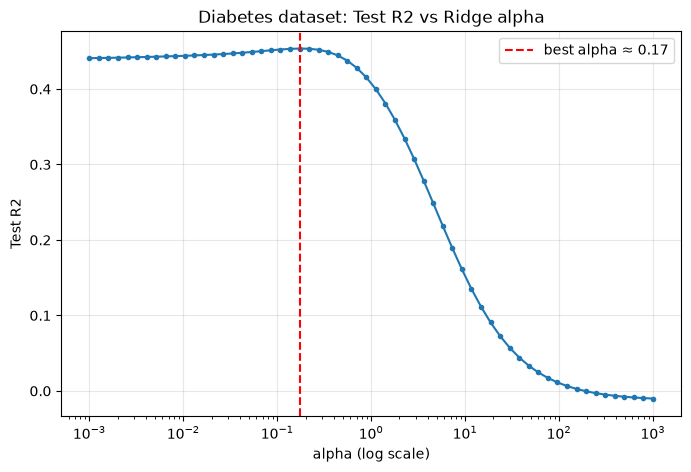

Best alpha ≈ 0.173  ->  Test R2 = 0.4536   (vs 0.4399 for plain Linear Regression)


In [16]:

# Now sweep alpha properly to find where Ridge actually helps
alphas_sweep = np.logspace(-3, 3, 60)
r2_scores = []
for a in alphas_sweep:
    r = Ridge(alpha=a).fit(Xd_train, yd_train)
    r2_scores.append(r2_score(yd_test, r.predict(Xd_test)))

best_alpha = alphas_sweep[np.argmax(r2_scores)]
best_r2 = max(r2_scores)

plt.figure(figsize=(8, 5))
plt.plot(alphas_sweep, r2_scores, marker='.')
plt.axvline(best_alpha, color='red', ls='--', label=f"best alpha ≈ {best_alpha:.2f}")
plt.xscale('log')
plt.xlabel("alpha (log scale)"); plt.ylabel("Test R2")
plt.title("Diabetes dataset: Test R2 vs Ridge alpha")
plt.legend()
plt.show()

print(f"Best alpha ≈ {best_alpha:.3f}  ->  Test R2 = {best_r2:.4f}"
      f"   (vs {r2_score(yd_test, yd_pred_lr):.4f} for plain Linear Regression)")



**Takeaway:** with the *right* alpha (found via sweeping / cross-validation, not guessed), Ridge gives a real, measurable improvement over plain Linear Regression on the diabetes dataset — not just the ~0.0001 nudge your notebook saw with a near-zero alpha. This motivates [Section 15](#15) — never hand-pick alpha, always tune it.



<a id="12"></a>
## 12. Why Standardization Matters for Ridge

The penalty term $\lambda\sum w_j^2$ treats **every coefficient equally**, in raw units. But if feature $x_1$ is measured in *thousands* (e.g. salary) and $x_2$ is measured in single digits (e.g. age), their coefficients naturally live on very different scales — $w_1$ might need to be tiny and $w_2$ large just to match units, **not because $x_1$ matters less**.

If you don't scale first, Ridge will unfairly shrink the coefficient of the naturally-larger-scale feature more/less than it "deserves," purely due to units — **not evidence**. This is the single most common practical mistake when using Ridge/Lasso.

> **Rule:** Always apply `StandardScaler` (mean 0, unit variance) to features *before* fitting Ridge (as we've done via `Pipeline` throughout this notebook). Ordinary Linear Regression doesn't need this because its coefficients are scale-*equivariant*; regularized regression is not.


In [17]:

# Demonstrate the problem
np.random.seed(4)
n = 200
x_small_scale = np.random.randn(n)                 # ~ range [-3, 3]
x_large_scale = np.random.randn(n) * 1000           # ~ range [-3000, 3000]
y_demo = 2 * x_small_scale + 0.002 * x_large_scale + np.random.randn(n) * 0.5
X_demo = np.column_stack([x_small_scale, x_large_scale])

# Without scaling
r_noscale = Ridge(alpha=10).fit(X_demo, y_demo)
print("WITHOUT scaling -> coefficients:", r_noscale.coef_, "  (unfairly penalizes the large-scale feature far less)")

# With scaling
X_demo_scaled = StandardScaler().fit_transform(X_demo)
r_scaled = Ridge(alpha=10).fit(X_demo_scaled, y_demo)
print("WITH scaling    -> coefficients:", r_scaled.coef_, "  (now comparable / fairly penalized)")


WITHOUT scaling -> coefficients: [1.95946933e+00 1.95281509e-03]   (unfairly penalizes the large-scale feature far less)
WITH scaling    -> coefficients: [1.88144184 1.88137387]   (now comparable / fairly penalized)



<a id="13"></a>
## 13. Ridge vs Lasso vs Elastic Net

Your notes list all three under "Ridge Regularization":  **1) Ridge (L2)  2) LASSO (L1)  3) Elastic Net**.

| | **Ridge (L2)** | **Lasso (L1)** | **Elastic Net** |
|---|---|---|---|
| Penalty | $\lambda\sum w_j^2$ | $\lambda\sum \lvert w_j\rvert$ | $\lambda_1\sum\lvert w_j\rvert + \lambda_2\sum w_j^2$ |
| Coefficients | Shrink smoothly, **never exactly 0** | Can shrink **exactly to 0** (automatic feature selection) | Mix of both behaviours |
| Best when | Many small/medium correlated predictors all matter | You suspect only a few features truly matter (sparse model) | Correlated features **and** you still want some sparsity |
| Geometry of constraint | Circle / sphere (smooth) | Diamond / cross-polytope (has sharp corners on the axes) | Rounded diamond |
| Multicollinearity | Handles very well — spreads weight across correlated features | Tends to arbitrarily pick one of several correlated features | Handles well (inherits Ridge's grouping effect) |
| sklearn class | `Ridge` | `Lasso` | `ElasticNet` |

Let's see the "exact-zero" difference directly, on the same data.


In [18]:

from sklearn.linear_model import Lasso, ElasticNet

# Reuse the multicollinear demo dataset from Section 8, expanded with a few pure-noise features
np.random.seed(5)
n = 100
x1 = np.random.randn(n)
x2 = x1 + np.random.randn(n) * 0.01       # near-duplicate of x1
noise_feats = np.random.randn(n, 4)       # 4 completely irrelevant features
X_cmp = np.column_stack([x1, x2, noise_feats])
y_cmp = 4 * x1 + 4 * x2 + np.random.randn(n) * 0.5

X_cmp_s = StandardScaler().fit_transform(X_cmp)

ridge_cmp = Ridge(alpha=1.0).fit(X_cmp_s, y_cmp)
lasso_cmp = Lasso(alpha=0.1).fit(X_cmp_s, y_cmp)
enet_cmp  = ElasticNet(alpha=0.1, l1_ratio=0.5).fit(X_cmp_s, y_cmp)

import pandas as pd
comparison = pd.DataFrame({
    "feature": ["x1", "x2 (~dup of x1)", "noise1", "noise2", "noise3", "noise4"],
    "Ridge":   np.round(ridge_cmp.coef_, 3),
    "Lasso":   np.round(lasso_cmp.coef_, 3),
    "ElasticNet": np.round(enet_cmp.coef_, 3),
})
comparison


,feature,Ridge,Lasso,ElasticNet
0,x1,3.771,7.374,3.635
1,x2 (~dup of x1),3.661,0.000,3.604
2,noise1,-0.010,-0.000,0.000
3,noise2,0.085,0.000,0.046
4,noise3,0.036,0.000,0.000
5,noise4,0.015,0.000,0.000



Notice: **Lasso zeroes out** the irrelevant noise features (and often one of the two correlated features), giving a sparse, easy-to-interpret model — while **Ridge keeps all of them small but non-zero**, spreading credit between `x1` and `x2` instead of arbitrarily picking one. **Elastic Net** sits in between.



<a id="14"></a>
## 14. When Should You Use Ridge Regression?

Your notes' final red-ink rule:
> **"Apply Ridge Regression when (X input / features) > 2."**

More completely (combining your note with standard ML guidance):

✅ **Use Ridge when:**
- You have **many features**, especially more features than you're fully confident are all independent (your note's ">2 features" is really shorthand for "more than a trivial number of predictors").
- Features are **correlated / multicollinear** — Ridge is specifically excellent here (Section 8).
- You believe **most/all features contribute a little** (no strong prior that most coefficients should be exactly zero).
- $p$ (features) is close to or greater than $n$ (samples), where OLS's $X^TX$ becomes singular or unstable (Section 5).
- You're fitting **high-degree polynomial features** and need to control overfitting without manually tuning the degree (Section 1/10).

❌ **Prefer Lasso / Elastic Net instead when:**
- You want automatic **feature selection** (suspect many features are irrelevant/noise).
- Model **interpretability via a sparse coefficient list** matters more than raw predictive accuracy.

❌ **Regularization isn't even needed when:**
- You have very few, well-chosen, uncorrelated features and plenty of data relative to $p$ — plain OLS is already well-behaved.



<a id="15"></a>
## 15. Hyperparameter Tuning — RidgeCV / GridSearchCV

We saw in [Section 11](#11) that picking alpha by hand (or leaving it at a default like `0.0001`) can hide most of Ridge's benefit. The right way is **cross-validation**. scikit-learn gives you two easy options:

- **`RidgeCV`** — built specifically for Ridge; efficiently tests many alphas using generalized/leave-one-out cross-validation internally (fast, no manual loop needed).
- **`GridSearchCV`** — general-purpose, works for any estimator/param grid, useful once you're combining Ridge with other pipeline steps.


In [19]:

from sklearn.linear_model import RidgeCV
from sklearn.model_selection import GridSearchCV, KFold

alphas_grid = np.logspace(-3, 3, 50)

# ---- Option A: RidgeCV (fast, purpose-built) ----
ridge_cv = RidgeCV(alphas=alphas_grid, cv=5)
ridge_cv.fit(Xd_train, yd_train)
print("RidgeCV best alpha:", ridge_cv.alpha_)
print("RidgeCV test R2   :", r2_score(yd_test, ridge_cv.predict(Xd_test)))

# ---- Option B: GridSearchCV (general purpose) ----
grid = GridSearchCV(Ridge(), param_grid={"alpha": alphas_grid},
                     cv=KFold(5, shuffle=True, random_state=0), scoring="r2")
grid.fit(Xd_train, yd_train)
print("\nGridSearchCV best alpha:", grid.best_params_["alpha"])
print("GridSearchCV best CV R2:", round(grid.best_score_, 4))
print("GridSearchCV test R2   :", r2_score(yd_test, grid.best_estimator_.predict(Xd_test)))


RidgeCV best alpha: 0.0517947467923121
RidgeCV test R2   : 0.44889651738684744

GridSearchCV best alpha: 0.004094915062380427
GridSearchCV best CV R2: 0.5078
GridSearchCV test R2   : 0.44247024525580514



Both approaches agree closely with the manually-swept "best alpha" found in Section 11 — confirming that **cross-validation, not guesswork, is how alpha should always be chosen in practice.**



<a id="16"></a>
## 🌟 16. 5 Key Tips (+ Bonus Practical Tips)

### The 5 core tips (from your notes, formalized):

1. **Ridge shrinks weights, it doesn't zero them.** As $\lambda\to\infty$, coefficients → 0 but never *equal* 0 — if you need automatic feature selection, use Lasso instead ([Section 13](#13)).
2. **Bigger weights get penalized disproportionately more**, because the penalty is quadratic ($\lambda w^2$) — this is *why* Ridge is so good at taming multicollinearity ([Section 8](#8)).
3. **Bias and variance both move with $\lambda$** — increasing $\lambda$ raises bias but lowers variance, and vice versa. There is no free lunch; the goal is the sweet spot, not the extreme ([Section 2](#2)).
4. **The intercept is never penalized** — only the slope/feature weights are (this shows up explicitly as `I[0][0]=0` in the matrix formula, [Section 5](#5)).
5. **Apply Ridge when you have more than a couple of features / suspect multicollinearity** — with very few, independent, well-understood features, plain OLS is often enough ([Section 14](#14)).

### Bonus practical tips:

6. **Always standardize features before fitting Ridge** — otherwise the penalty is unfairly distributed based on arbitrary units ([Section 12](#12)).
7. **Never hand-pick alpha** — use `RidgeCV` / `GridSearchCV` with proper cross-validation ([Section 15](#15)).
8. **Ridge has a closed-form solution** (Normal Equation, [Section 5](#5)) *and* a gradient-descent solution ([Section 6](#6)) — the closed form is exact but $O(p^3)$; gradient descent scales better to very large $p$.
9. **Watch out for the "solver" and "normalize" deprecations** in scikit-learn — older tutorials (including patterns like your own notebook's `Ridge(alpha=0.0001)` call) may use a now-removed `normalize=True` argument; use an explicit `StandardScaler` in a `Pipeline` instead (as done throughout this notebook).
10. **A near-zero alpha (like `0.0001`) barely regularizes anything** — if your R² barely moves after adding Ridge, it's often *not* evidence Ridge doesn't help; it may just mean alpha is too small to matter. Always sweep a *log-scale* range of alphas (e.g. `np.logspace(-3, 3, ...)`) before concluding anything ([Section 11](#11)).
11. **Ridge assumes a linear relationship between the (possibly polynomial/engineered) features and the target** — it regularizes coefficients, but it can't fix an entirely wrong functional form; you may still need feature engineering (like `PolynomialFeatures`) first.
12. **For very high-dimensional/sparse data (e.g. text with huge one-hot/TF-IDF matrices)**, Ridge is often paired with dimensionality reduction or Elastic Net, since pure Ridge keeps *every* feature (which can be memory/compute-heavy at huge scale) even though it never removes any.



<a id="17"></a>
## 17. Summary Cheat-Sheet

| Concept | Formula / Fact |
|---|---|
| Ridge loss | $L=\sum(y_i-\hat y_i)^2+\lambda\sum w_j^2$ |
| Simple (1-feature) closed form | $m=\dfrac{\sum(x_i-\bar x)(y_i-\bar y)}{\sum(x_i-\bar x)^2+\lambda}$,  $b=\bar y-m\bar x$ |
| Multiple (matrix) closed form | $w=(X^TX+\lambda I')^{-1}X^Ty$, with $I'_{00}=0$ |
| Gradient (per weight) | $\dfrac{\partial L}{\partial w_j}=-2\sum x_{ij}(y_i-\hat y_i)+2\lambda w_j$ |
| $\lambda=0$ | Identical to OLS |
| $\lambda\to\infty$ | All coefficients → 0 (never exactly 0) |
| Penalizes intercept? | ❌ No |
| Can zero out coefficients? | ❌ No (use Lasso for that) |
| Handles multicollinearity? | ✅ Yes, very well |
| Needs feature scaling? | ✅ Yes, essential |
| Alpha selection | Use `RidgeCV` / `GridSearchCV`, never guess |
| Use when | Many/correlated features, $p$ close to $n$, high-degree polynomial models |



<a id="18"></a>
## 18. References

- **Wikipedia** — [Ridge regression / Tikhonov regularization](https://en.wikipedia.org/wiki/Ridge_regression)
- **GeeksforGeeks** — [What is Ridge Regression?](https://www.geeksforgeeks.org/machine-learning/what-is-ridge-regression/)
- **scikit-learn official docs** — [Ridge Regression & Classification](https://scikit-learn.org/stable/modules/linear_model.html#ridge-regression-and-classification)
- **scikit-learn API reference** — [`sklearn.linear_model.Ridge`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html), [`RidgeCV`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html)
- **An Introduction to Statistical Learning (ISLR)**, James, Witten, Hastie, Tibshirani — Chapter 6: Linear Model Selection and Regularization (Ridge Regression & the Lasso)
- Your own handwritten notes & `RidgeRegularization.ipynb` / `Ridge___polynomial_Regression_annotated.pdf` (100 Days of ML series) — the backbone this notebook was built around ❤️

---

### 🎓 You now have, in one file:
✅ The overfitting problem that motivates regularization &nbsp;•&nbsp; ✅ Bias-variance tradeoff &nbsp;•&nbsp; ✅ Full simple + matrix-form derivations &nbsp;•&nbsp; ✅ Gradient descent derivation &nbsp;•&nbsp; ✅ Geometric intuition &nbsp;•&nbsp; ✅ Ridge trace &nbsp;•&nbsp; ✅ A corrected, working from-scratch implementation &nbsp;•&nbsp; ✅ Real dataset practice &nbsp;•&nbsp; ✅ Ridge vs Lasso vs ElasticNet &nbsp;•&nbsp; ✅ When to use it &nbsp;•&nbsp; ✅ Proper hyperparameter tuning &nbsp;•&nbsp; ✅ Key tips & cheat sheet.
